# Titanic Survival Rater — Visualization Notebook

This notebook is only for exploring and visualizing the dataset.

It imports code from `src/` so you don’t copy/paste preprocessing logic.


In [6]:
import seaborn
import matplotlib.pyplot as plt

from src.data import load_raw, preprocess

seaborn.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [7]:
raw = load_raw()
processed = preprocess(raw, save=False)

print("Raw shape:", raw.shape)
print("Processed shape:", processed.shape)
raw.head()

Raw shape: (1313, 11)
Processed shape: (1313, 7)


,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
0,1,1st,1,"Allen, Miss Elisabeth Walton",29.0000,Southampton,"St Louis, MO",B-5,24160 L221,2,female
1,2,1st,0,"Allison, Miss Helen Loraine",2.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
2,3,1st,0,"Allison, Mr Hudson Joshua Creighton",30.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,-135,male
3,4,1st,0,"Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)",25.0000,Southampton,"Montreal, PQ / Chesterville, ON",C26,NaN,NaN,female
4,5,1st,1,"Allison, Master Hudson Trevor",0.9167,Southampton,"Montreal, PQ / Chesterville, ON",C22,NaN,11,male


## Missing values (raw)

This shows which columns have the most missing data. This is usually the first reason we need preprocessing.


ticket       0.947449
room         0.941356
boat         0.735720
age          0.517898
home.dest    0.425743
embarked     0.374714
pnumber      0.000000
survived     0.000000
pclass       0.000000
name         0.000000
sex          0.000000
dtype: float64

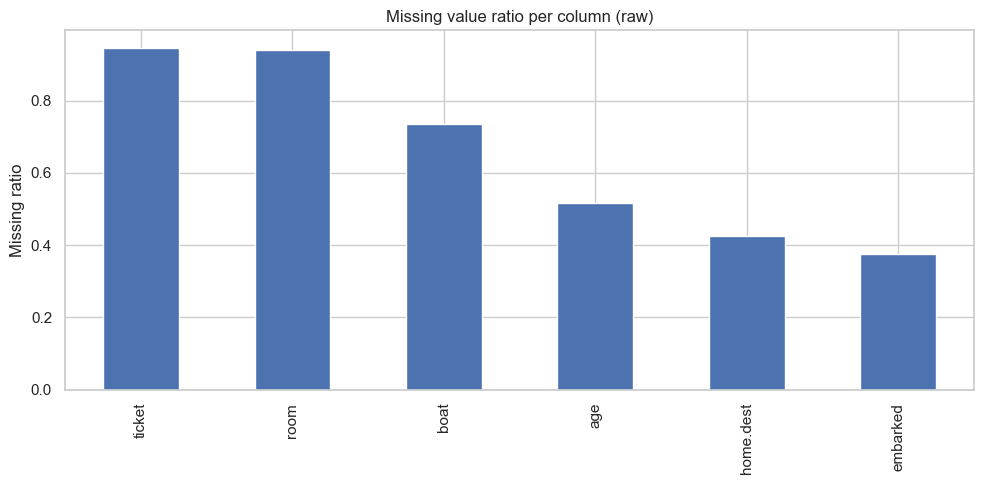

In [8]:
missing = raw.isna().mean().sort_values(ascending=False)
display(missing)

ax = missing[missing > 0].plot(kind="bar")
ax.set_title("Missing value ratio per column (raw)")
ax.set_ylabel("Missing ratio")
plt.tight_layout()
plt.show()

## Survival by sex and passenger class

These plots show why `sex` and `pclass` are strong signals for survival in this dataset.


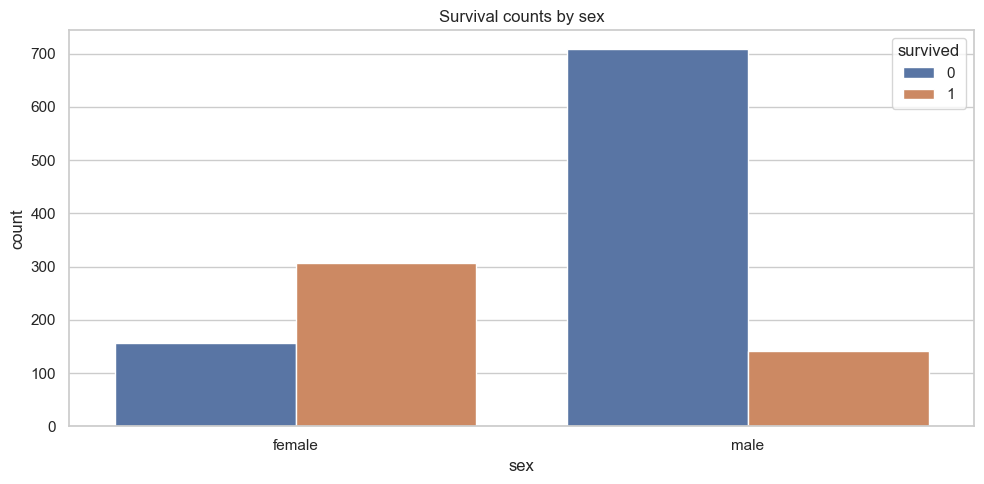

sex
female    0.663067
male      0.167059
Name: survived, dtype: float64

pclass
1st    0.599379
2nd    0.425000
3rd    0.192686
Name: survived, dtype: float64

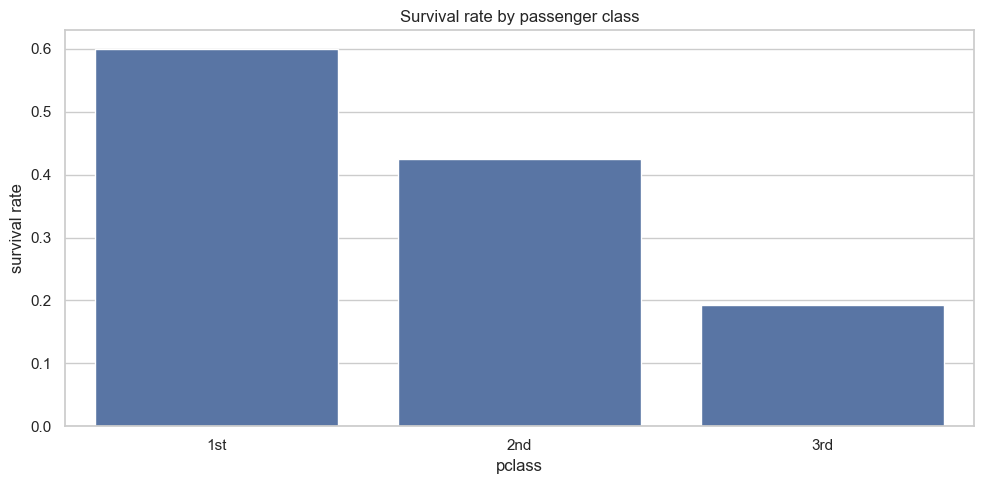

In [9]:
# Survival counts by sex
seaborn.countplot(data=raw, x="sex", hue="survived")
plt.title("Survival counts by sex")
plt.tight_layout()
plt.show()

# Survival rate by sex
rate_by_sex = raw.groupby("sex")["survived"].mean().sort_values(ascending=False)
display(rate_by_sex)

# Survival rate by class
rate_by_class = raw.groupby("pclass")["survived"].mean().sort_values(ascending=False)
display(rate_by_class)

seaborn.barplot(x=rate_by_class.index, y=rate_by_class.values)
plt.title("Survival rate by passenger class")
plt.xlabel("pclass")
plt.ylabel("survival rate")
plt.tight_layout()
plt.show()

## Age distribution (raw)

Age has missing values, so we drop missing ages just for this visualization.


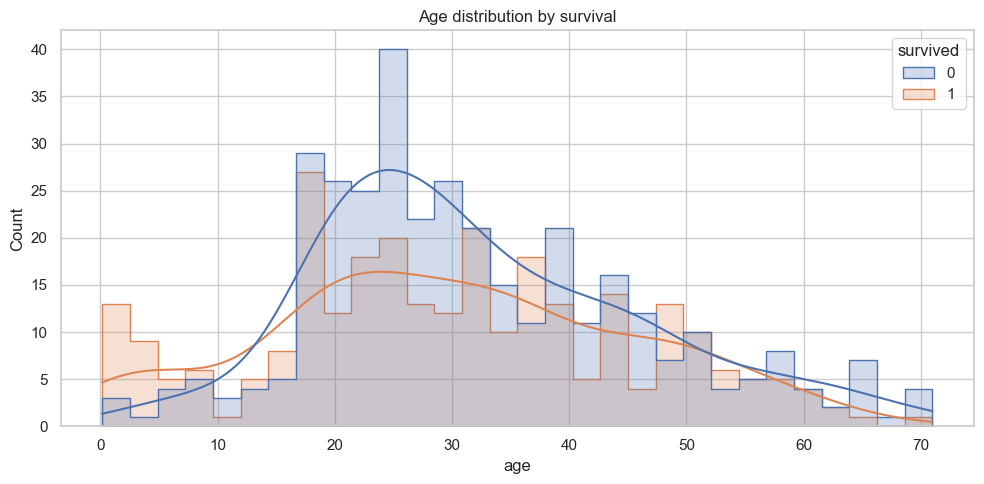

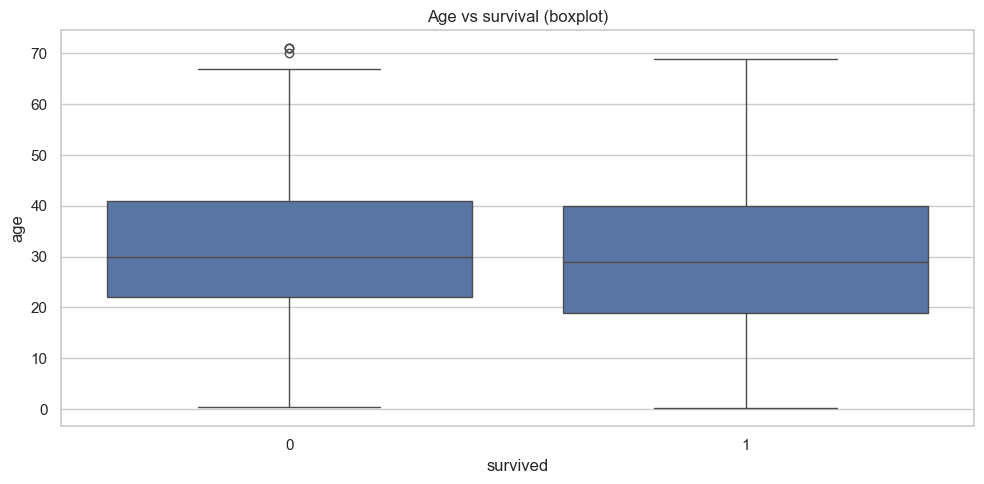

In [ ]:
age_df = raw.dropna(subset=["age"]).copy()

sns.histplot(data=age_df, x="age", hue="survived", bins=30, kde=True, element="step")
plt.title("Age distribution by survival")
plt.tight_layout()
plt.show()

sns.boxplot(data=age_df, x="survived", y="age")
plt.title("Age vs survival (boxplot)")
plt.tight_layout()
plt.show()

## Correlation heatmap (processed)

We use the processed dataset here because it is numeric. We fill missing ages with the median so correlation can be computed cleanly.


## Simpler view: correlation with survival only

Instead of a full heatmap, this chart shows how strongly each feature is related to `survived`. Higher absolute value = stronger relationship.

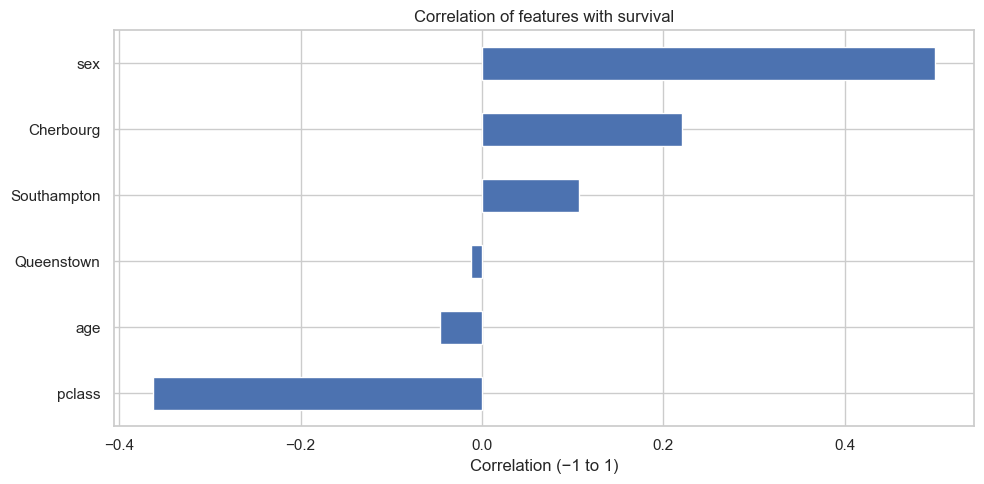

In [12]:
# Recompute correlation here so this cell works even if you run it alone
corr_df2 = processed.copy()
if "age" in corr_df2.columns:
    corr_df2["age"] = corr_df2["age"].fillna(corr_df2["age"].median())

corr2 = corr_df2.corr(numeric_only=True)

corr_with_survived = corr2["survived"].drop("survived")

ax = corr_with_survived.sort_values().plot(kind="barh")
ax.set_title("Correlation of features with survival")
ax.set_xlabel("Correlation (−1 to 1)")
plt.tight_layout()
plt.show()
